---

_You are currently looking at **version 1.1** of this notebook. To download notebooks and datafiles, as well as get help on Jupyter notebooks in the Coursera platform, visit the [Jupyter Notebook FAQ](https://www.coursera.org/learn/python-social-network-analysis/resources/yPcBs) course resource._

---

# 1. Creating and Manipulating Graphs

Eight employees at a small company were asked to choose 3 movies that they would most enjoy watching for the upcoming company movie night. These choices are stored in the file `Employee_Movie_Choices.txt`.

A second file, `Employee_Relationships.txt`, has data on the relationships between different coworkers. 

The relationship score has value of `-100` (Enemies) to `+100` (Best Friends). A value of zero means the two employees haven't interacted or are indifferent.

Both files are tab delimited.

In [36]:
#import pip
#pip.main(['install', 'scipy'])
import networkx as nx
import pandas as pd
import numpy as np
from networkx.algorithms import bipartite
import matplotlib.pyplot as plt
import graphviz
#import scipy
%matplotlib inline

# This is the set of employees
employees = set(['Pablo',
                 'Lee',
                 'Georgia',
                 'Vincent',
                 'Andy',
                 'Frida',
                 'Joan',
                 'Claude'])

# This is the set of movies
movies = set(['The Shawshank Redemption',
              'Forrest Gump',
              'The Matrix',
              'Anaconda',
              'The Social Network',
              'The Godfather',
              'Monty Python and the Holy Grail',
              'Snakes on a Plane',
              'Kung Fu Panda',
              'The Dark Knight',
              'Mean Girls'])


# you can use the following function to plot graphs
# make sure to comment it out before submitting to the autograder
def plot_graph(G, weight_name=None):
    '''
    G: a networkx G
    weight_name: name of the attribute for plotting edge weights (if G is weighted)
    '''
    #%matplotlib notebook
    
    plt.figure(figsize=(15,15))
    pos = nx.spring_layout(G)
    edges = G.edges()
    weights = None
    
    if weight_name:
        weights = [int(G[u][v][weight_name]) for u,v in edges]
        labels = nx.get_edge_attributes(G,weight_name)
        nx.draw_networkx_edge_labels(G,pos,edge_labels=labels)
        nx.draw_networkx(G, pos, edges=edges, width=weights);
    else:
        nx.draw_networkx(G, pos, edges=edges);

### Question 1

Using NetworkX, load in the bipartite graph from `Employee_Movie_Choices.txt` and return that graph.

*This function should return a networkx graph with 19 nodes and 24 edges*

,Employee,Movie
0,Andy,Anaconda
1,Andy,Mean Girls
2,Andy,The Matrix
3,Claude,Anaconda
4,Claude,Monty Python and the Holy Grail
5,Claude,Snakes on a Plane
6,Frida,The Matrix
7,Frida,The Shawshank Redemption
8,Frida,The Social Network
9,Georgia,Anaconda


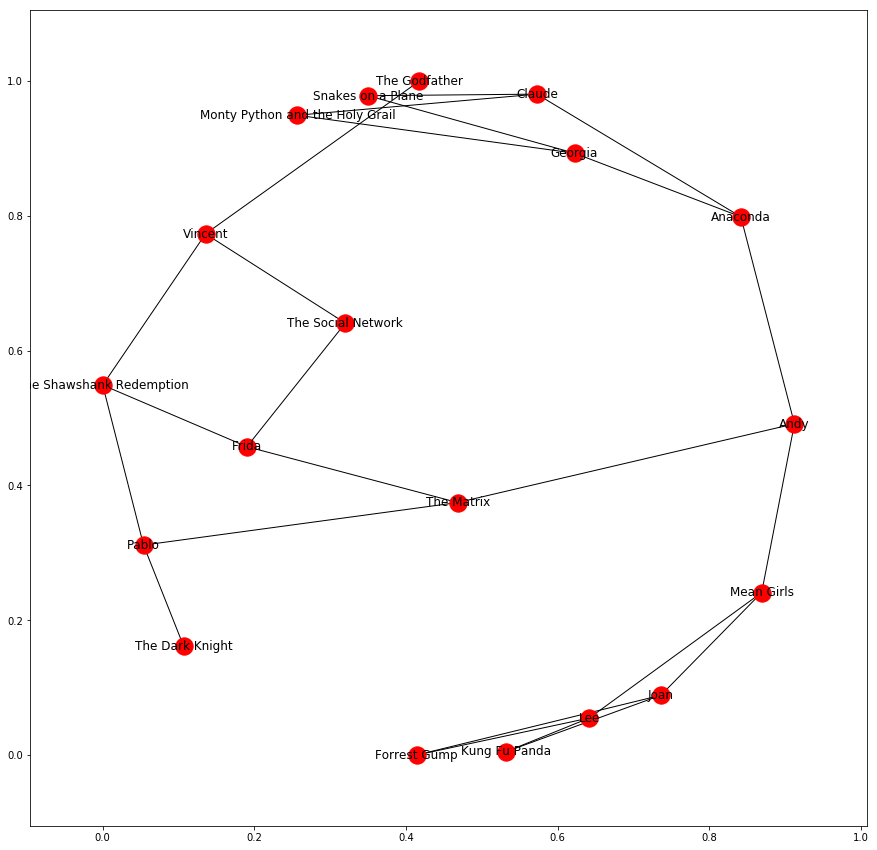

In [102]:
from graphviz import Graph
s = Graph('crossmatch', node_attr={'shape': 'plaintext'}, format='png') #,engine='neato')
s.body.extend(['rankdir=LR'])

def answer_one():
        
    # Your Code Here
    input = open("C:\courses\Coursera\Past\Specialization-UMich Applied Data Science with Python\Social Network Analysis Python\Week1\Employee_Movie_Choices.txt", "r")
    lines =  input.read().splitlines()
    df = pd.DataFrame()
    G = nx.Graph()
    for line in lines[1:]:
        A, B = line.split('\t')
        #print(A,'|', B)
        G.add_edge(A,B)
        s.attr('node', style='filled', color='lightblue2', shape='circle')
        s.node('A'+str(A),str(A))
        s.attr('node', style='filled', color='green', shape='circle')
        s.node('B'+str(B),str(B),**{'width':'1', 'height':'1'})
        s.edge('A'+str(A), 'B'+str(B))
        df = df.append({'Employee': A, 'Movie': B}, ignore_index=True)
    #print (len(G.nodes()), len(G.edges()))    
    s.render('C:\courses\Coursera\Past\Specialization-UMich Applied Data Science with Python\Social Network Analysis Python\Week1\em', view=False)
    return G, df # Your Answer Here
G, df = answer_one()
plot_graph(G)
df

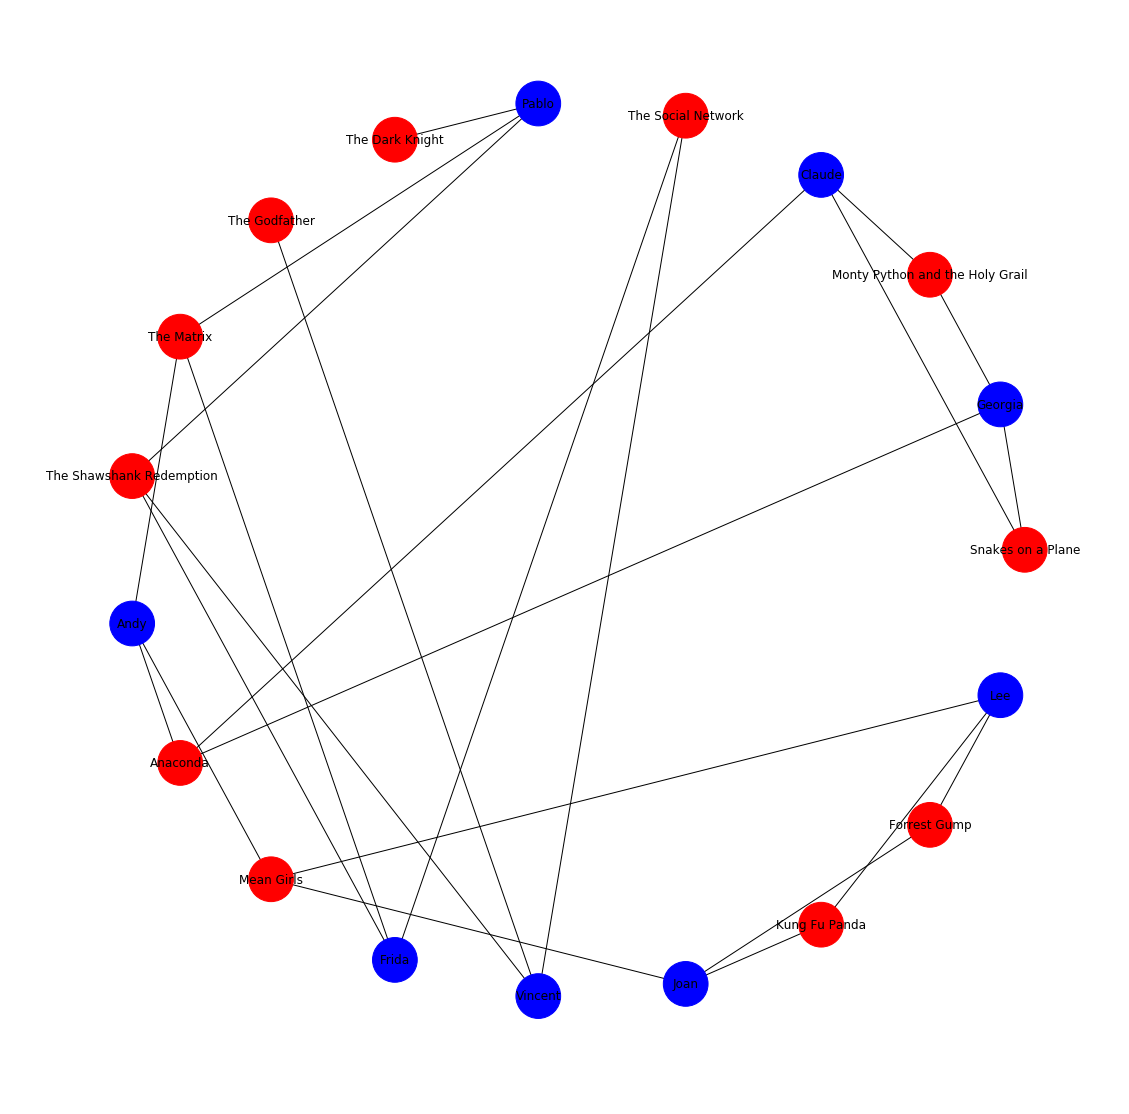

In [103]:
plt.figure(figsize=(15,15))
nx.draw_circular(G, node_color = ['blue' if n in employees else 'red' for n in G.nodes()], with_labels = True, node_size=2000)

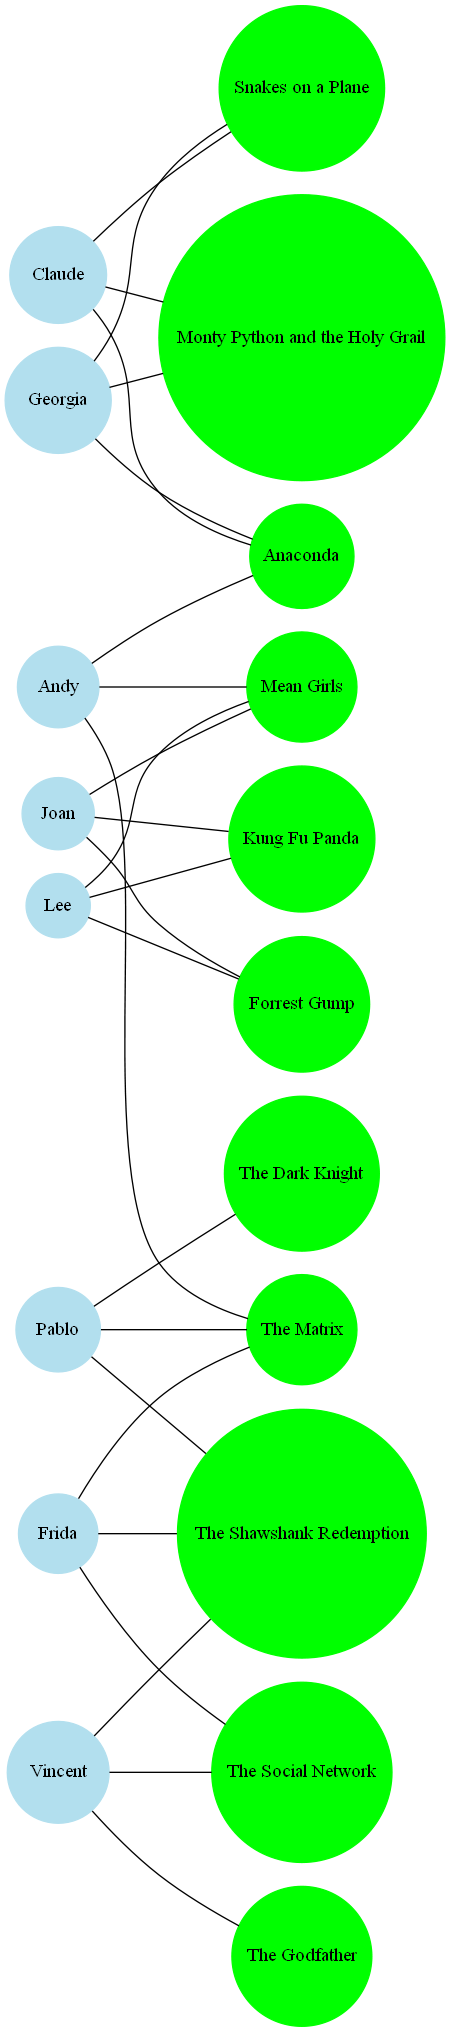

In [30]:
from IPython.display import Image
Image(filename='C:\courses\Coursera\Past\Specialization-UMich Applied Data Science with Python\Social Network Analysis Python\Week1\em.png')#,width=200, height=2000)

### Question 2

Using the graph from the previous question, add nodes attributes named `'type'` where movies have the value `'movie'` and employees have the value `'employee'` and return that graph.

*This function should return a networkx graph with node attributes `{'type': 'movie'}` or `{'type': 'employee'}`*

[('Snakes on a Plane', {'type': 'movie'}), ('Georgia', {'type': 'employee'}), ('Monty Python and the Holy Grail', {'type': 'movie'}), ('Claude', {'type': 'employee'}), ('The Social Network', {'type': 'movie'}), ('Pablo', {'type': 'employee'}), ('The Dark Knight', {'type': 'movie'}), ('The Godfather', {'type': 'movie'}), ('The Matrix', {'type': 'movie'}), ('The Shawshank Redemption', {'type': 'movie'}), ('Andy', {'type': 'employee'}), ('Anaconda', {'type': 'movie'}), ('Mean Girls', {'type': 'movie'}), ('Frida', {'type': 'employee'}), ('Vincent', {'type': 'employee'}), ('Joan', {'type': 'employee'}), ('Kung Fu Panda', {'type': 'movie'}), ('Forrest Gump', {'type': 'movie'}), ('Lee', {'type': 'employee'})]


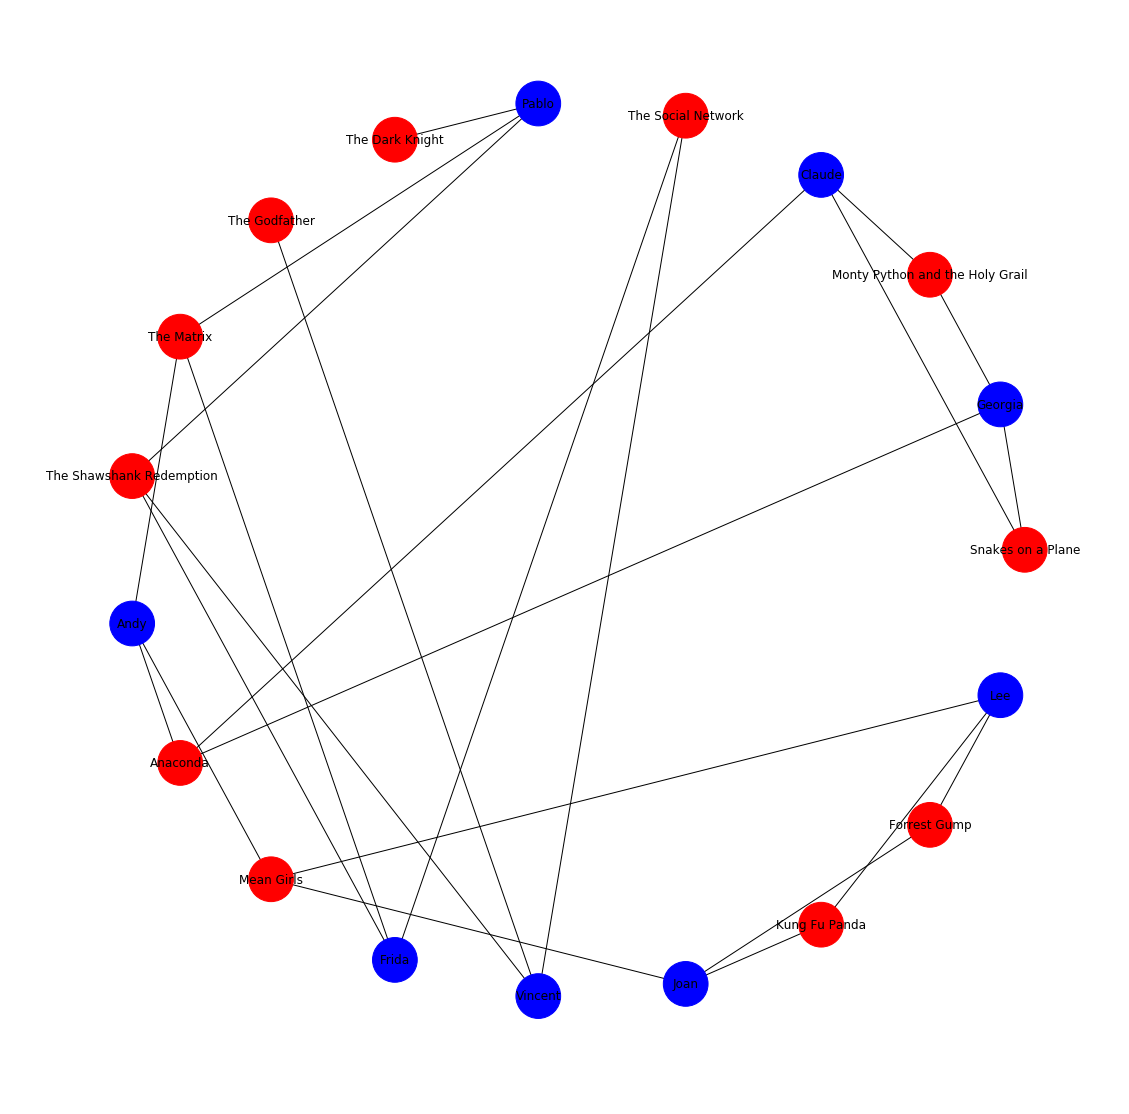

In [109]:
def answer_two():
    
    # Your Code Here
    G, df = answer_one()
    n = set(G.nodes())
    e = set(['Andy', 'Claude', 'Frida', 'Georgia', 'Joan', 'Lee', 'Pablo', 'Vincent'])
    m = n - e
    G.add_nodes_from(e, type='employee')
    G.add_nodes_from(m, type='movie')
    #for (e, m) in G.edges():
    #    if G.node[e].get('type', None) == None:
    #        G.add_node(e, type='employee')
    #    if G.node[m].get('type', None) == None:
    #        G.add_node(m, type='movie')
    return G # Your Answer Here

G = answer_two()
print(G.nodes(data=True))
#plot_graph(G)
plt.figure(figsize=(15,15))
nx.draw_circular(G, node_color = ['blue' if n[1]['type'] == 'employee' else 'red' for n in G.nodes(data=True)], with_labels = True, node_size=2000)

### Question 3

Find a weighted projection of the graph from `answer_two` which tells us how many movies different pairs of employees have in common.

*This function should return a weighted projected graph.*

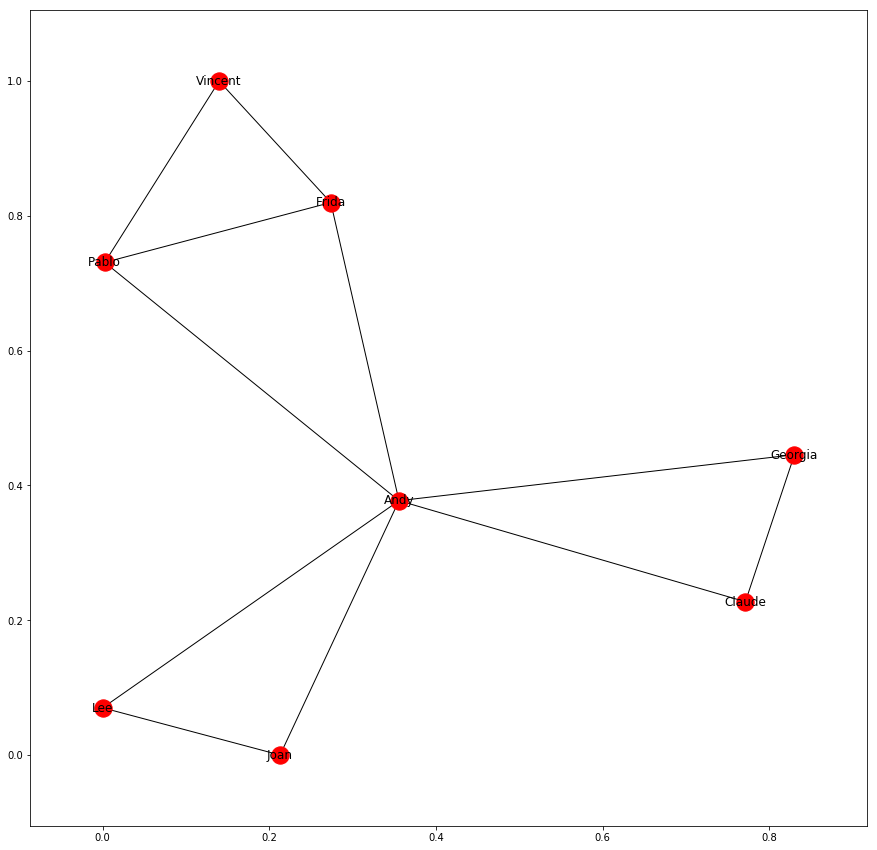

In [110]:
def answer_three():
        
    # Your Code Here
    G = answer_two()
    #movies = set([n for n in G.nodes() if G.node[n]['type']=='movie'])
    #return bipartite.weighted_projected_graph(G, movies) # Your Answer Here
    employees = set([n for n in G.nodes() if G.node[n]['type']=='employee'])
    return bipartite.weighted_projected_graph(G, employees) # Your Answer Here
G = answer_three()
plot_graph(G)

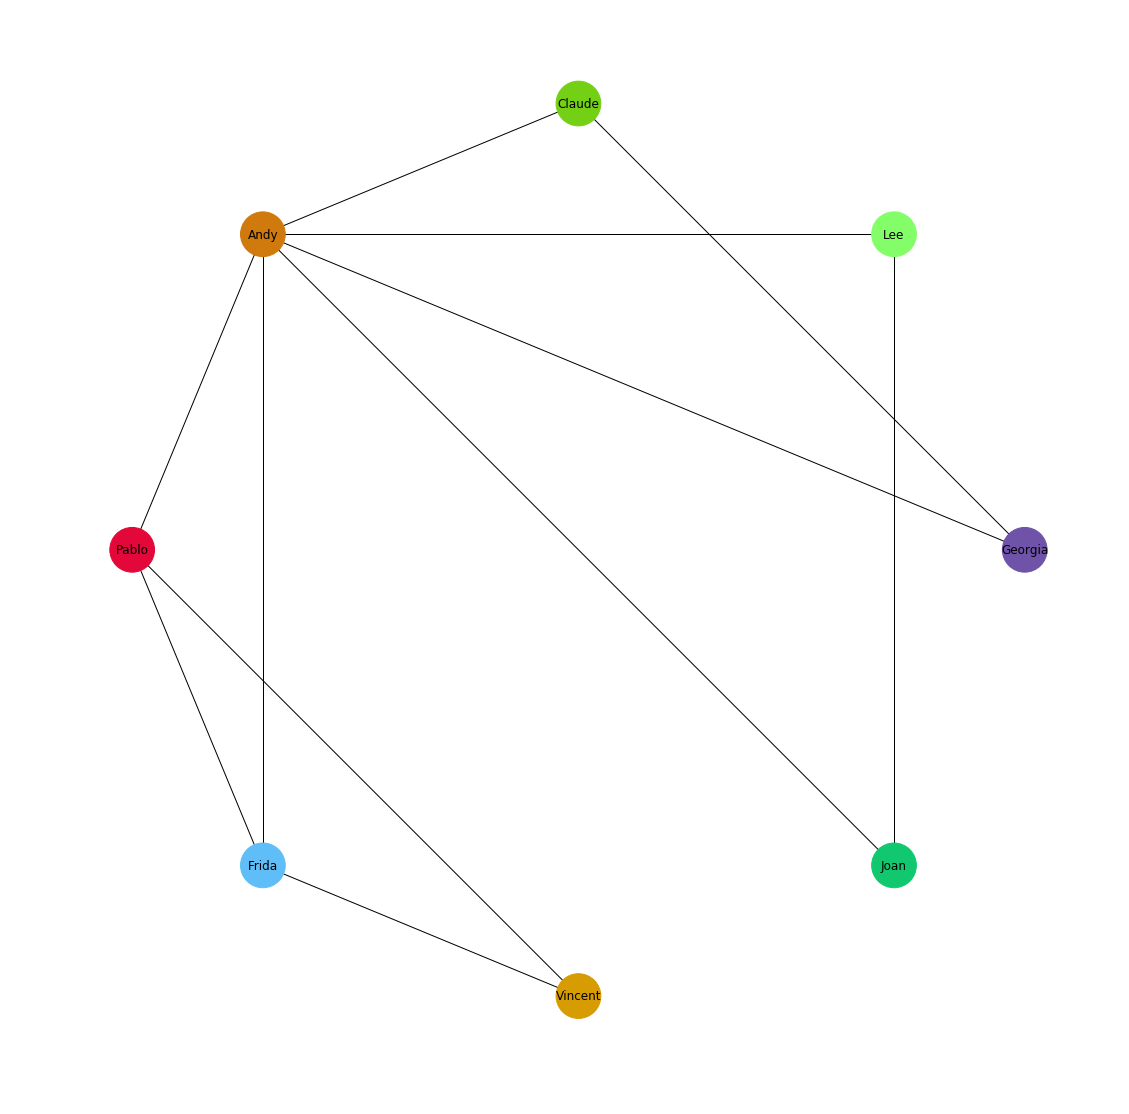

In [113]:
colors = [(random(), random(), random()) for _i in range(10)]
plt.figure(figsize=(15,15))
nx.draw_circular(G, with_labels = True, node_size=2000, node_color=colors)

### Question 4

Suppose you'd like to find out if people that have a high relationship score also like the same types of movies.

Find the Pearson correlation ( using `DataFrame.corr()` ) between employee relationship scores and the number of movies they have in common. If two employees have no movies in common it should be treated as a 0, not a missing value, and should be included in the correlation calculation.

*This function should return a float.*

In [117]:
def answer_four():
        
    # Your Code Here
    df = pd.read_csv("C:\courses\Coursera\Past\Specialization-UMich Applied Data Science with Python\Social Network Analysis Python\Week1\Employee_Relationships.txt", sep="\t", header=None)
    df.columns = ['e1', 'e2', 'score']
    df1 = df.copy()
    df1['e1'], df1['e2'] = df['e2'], df['e1']
    df = df.append(df1)
    dfe = df
    #print(df)
    G = answer_three()
    df1 = pd.DataFrame()
    for (e1, e2) in G.edges():
        df1 = df1.append({'e1': e1, 'e2': e2, 'weight': G.edge[e1][e2]['weight']}, ignore_index=True)
        df1 = df1.append({'e1': e2, 'e2': e1, 'weight': G.edge[e1][e2]['weight']}, ignore_index=True)
    #print(df1)
    dfp = df1
    df = df.merge(df1, left_on=['e1', 'e2'], right_on=['e1', 'e2'], how='outer')
    df.fillna(0, inplace=True)
    #print(df)
    return df['score'].corr(df['weight'], method='pearson'), df, dfe, dfp # Your Answer Here
sc, df, dfe, dfp = answer_four()
dfe

,e1,e2,score
0,Andy,Claude,0
1,Andy,Frida,20
2,Andy,Georgia,-10
3,Andy,Joan,30
4,Andy,Lee,-10
5,Andy,Pablo,-10
6,Andy,Vincent,20
7,Claude,Frida,0
8,Claude,Georgia,90
9,Claude,Joan,0


In [ ]:
dfp

In [52]:
df

,e1,e2,score,weight
0,Andy,Claude,0,1.0
1,Andy,Frida,20,1.0
2,Andy,Georgia,-10,1.0
3,Andy,Joan,30,1.0
4,Andy,Lee,-10,1.0
5,Andy,Pablo,-10,1.0
6,Andy,Vincent,20,0.0
7,Claude,Frida,0,0.0
8,Claude,Georgia,90,3.0
9,Claude,Joan,0,0.0


{('Andy', 'Frida'): <matplotlib.text.Text at 0x25a85c50>,
 ('Andy', 'Joan'): <matplotlib.text.Text at 0x2a7f58d0>,
 ('Andy', 'Pablo'): <matplotlib.text.Text at 0x2a808860>,
 ('Andy', 'Vincent'): <matplotlib.text.Text at 0x2a8ba358>,
 ('Claude', 'Andy'): <matplotlib.text.Text at 0x2556c9b0>,
 ('Claude', 'Frida'): <matplotlib.text.Text at 0x2a808358>,
 ('Claude', 'Joan'): <matplotlib.text.Text at 0x2a8bfac8>,
 ('Claude', 'Pablo'): <matplotlib.text.Text at 0x2a8ba9e8>,
 ('Claude', 'Vincent'): <matplotlib.text.Text at 0x2556d908>,
 ('Frida', 'Joan'): <matplotlib.text.Text at 0x2a8bffd0>,
 ('Frida', 'Vincent'): <matplotlib.text.Text at 0x2a8bf1d0>,
 ('Georgia', 'Andy'): <matplotlib.text.Text at 0x2a8ab668>,
 ('Georgia', 'Claude'): <matplotlib.text.Text at 0x2556cfd0>,
 ('Georgia', 'Frida'): <matplotlib.text.Text at 0x2a808978>,
 ('Georgia', 'Joan'): <matplotlib.text.Text at 0x2a8ab780>,
 ('Georgia', 'Lee'): <matplotlib.text.Text at 0x25565be0>,
 ('Georgia', 'Pablo'): <matplotlib.text.Text a

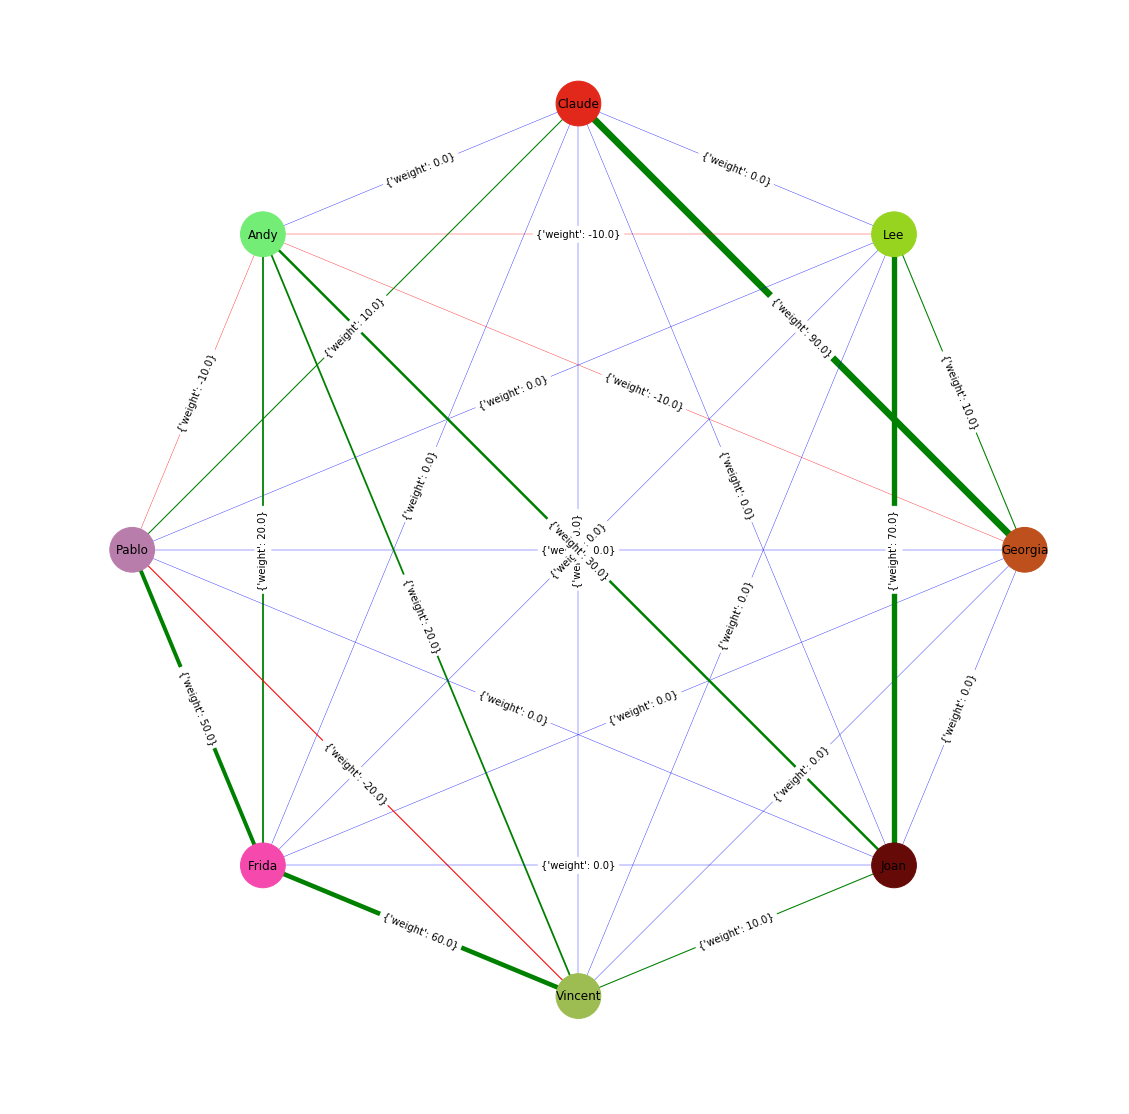

In [119]:
from random import random
dfe['e1'] = dfe['e1'].astype('str')
dfe['e2'] = dfe['e2'].astype('str')
dfe['score'] = dfe['score'].astype('float64')
G = nx.Graph()
for i in range(df.shape[0]):
    G.add_edge(dfe.iloc[i]['e1'],dfe.iloc[i]['e2'],weight=dfe.iloc[i]['score'])
#plot_graph(G)
plt.figure(figsize=(15,15))
colors = [(random(), random(), random()) for _i in range(10)]
edges = G.edges()
ecolors = ['green' if G[u][v]['weight'] > 0 else 'blue' if G[u][v]['weight'] == 0 else 'red' for u,v in edges]
weights = [5*(G[u][v]['weight']+5.)/70. for u,v in edges]
nx.draw_circular(G, with_labels = True, node_size=2000, node_color=colors, edge_color=ecolors, width=weights)
nx.draw_networkx_edge_labels(G,pos=nx.circular_layout(G))

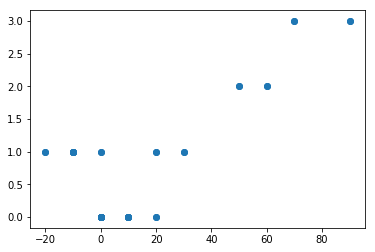

In [120]:
import matplotlib.pylab as plt
plt.scatter(df['score'], df['weight'])

In [121]:
#import pip
#pip.main(['install', 'C:\courses\Coursera\Past\Specialization-UMich Applied Data Science with Python\Social Network Analysis Python\Week1\scipy-0.18.0rc2-cp27-cp27m-win_amd64.whl'])
#pip.main(['install', 'C:\courses\Coursera\Past\Specialization-UMich Applied Data Science with Python\Social Network Analysis Python\Week1\seaborn-0.8.1-py2.py3-none-any.whl'])
#pip.main(['install', 'C:\courses\Coursera\Past\Specialization-UMich Applied Data Science with Python\Social Network Analysis Python\Week1\\numpy-1.11.1+mkl-cp27-cp27m-win_amd64.whl'])

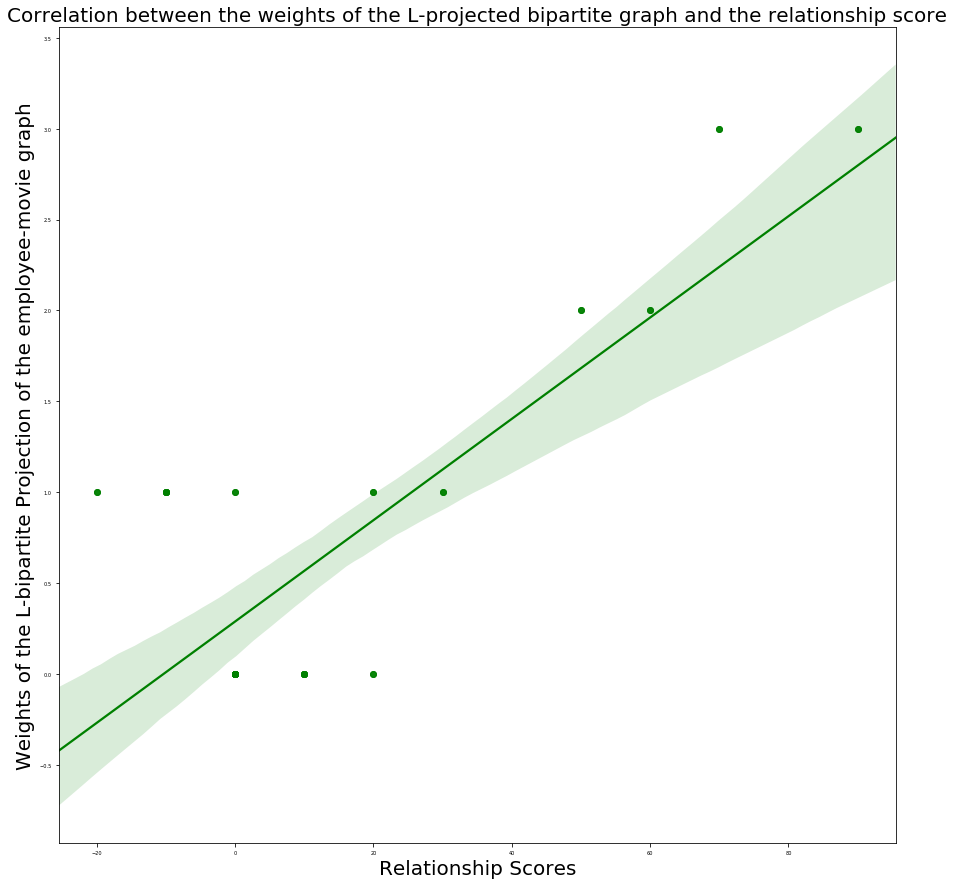

In [122]:
import seaborn as sns
plt.figure(figsize=(15,15))
b = sns.regplot(df['score'], df['weight'], color="g")
b.axes.set_title("Correlation between the weights of the L-projected bipartite graph and the relationship score",fontsize=20)
b.set_xlabel("Relationship Scores",fontsize=20)
b.set_ylabel("Weights of the L-bipartite Projection of the employee-movie graph",fontsize=20)
b.tick_params(labelsize=5)
#sns.plt.show()